In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [2]:
meta_all = pd.read_csv(f"./stratified_splits/fold_summary.csv")
describe_all = pd.DataFrame(columns=['mean', 'min', 'max', 'std'])

for k in range(0, 10):
    score_k = np.load(f"./self_attri/trak/fold_{k}.npy")
    meta_k = pd.read_csv(f"./stratified_splits/fold_{k}/train.csv")
    
    # save scores to columns
    df_k = meta_k.copy(deep=True)
    df_k[f'score_{k}'] = score_k
    
    meta_all = meta_all.merge(df_k[['filepath', f'score_{k}']], on='filepath', how='outer')
    
    # save score stats
    describe_all.loc[k, 'mean'] = df_k[f'score_{k}'].mean()
    describe_all.loc[k, 'min']  = df_k[f'score_{k}'].min()
    describe_all.loc[k, 'max']  = df_k[f'score_{k}'].max()
    describe_all.loc[k, 'std']  = df_k[f'score_{k}'].std()


In [5]:
meta_all.to_csv(f"./self_attri/trak/meta_scores.csv")

In [ ]:
score_cols = [f"score_{k}" for k in range(0,10)]

meta_all['avg_unnormalized'] = meta_all[score_cols].mean(axis=1)
# meta_all['rank_unnormalized'] = meta_all['avg_unnormalized'].rank(ascending=False, method='dense').astype(int)
meta_all['rank_unnormalized'] = meta_all['avg_unnormalized'].rank(ascending=True, method='dense').astype('Int64')

norm_cols = [f'{col}_norm' for col in score_cols]
meta_all[norm_cols] = MinMaxScaler().fit_transform(meta_all[score_cols])
meta_all['avg_normalized'] = meta_all[norm_cols].mean(axis=1)
# meta_all['rank_normalized'] = meta_all['avg_normalized'].rank(ascending=False, method='dense').astype(int)
meta_all['rank_normalized'] = meta_all['avg_normalized'].rank(ascending=True, method='dense').astype('Int64')


# avg of ranks
for col in score_cols:
    meta_all[f'{col}_rank'] = meta_all[col].rank(ascending=True, method='dense').astype('Int64')

rank_cols = [f'{col}_rank' for col in score_cols]
meta_all['avg_rank'] = meta_all[rank_cols].mean(axis=1)


In [36]:
cols = ['filepath', 'rank_unnormalized', 'rank_normalized', 'avg_rank']
meta_ranks = meta_all[cols]

In [ ]:
meta_ranks = meta_ranks.sort_values(by='rank_normalized', ascending=True)
meta_ranks

,filepath,rank_unnormalized,rank_normalized,avg_rank
325,./gtzan/disco/disco.00025.wav,28,1,275.625
710,./gtzan/pop/pop.00010.wav,18,2,495.875
420,./gtzan/hiphop/hiphop.00020.wav,54,3,352.5
404,./gtzan/hiphop/hiphop.00004.wav,78,4,388.125
764,./gtzan/pop/pop.00064.wav,10,5,334.75
...,...,...,...,...
680,./gtzan/metal/metal.00080.wav,986,996,479.0
888,./gtzan/reggae/reggae.00088.wav,913,997,497.5
487,./gtzan/hiphop/hiphop.00087.wav,947,998,259.375
988,./gtzan/rock/rock.00088.wav,993,999,420.0


# Read Metadata

In [5]:
meta_read = pd.read_csv("all_mislabels_result.csv")
meta_read.head()

,Precision@5%,Recall@5%,F1@5%,Precision@10%,Recall@10%,F1@10%,Precision@20%,Recall@20%,F1@20%
0,0.54,0.16,0.25,0.46,0.28,0.35,0.35,0.42,0.38
1,0.28,0.08,0.13,0.20,0.12,0.15,0.16,0.20,0.18
2,0.56,0.17,0.26,0.47,0.28,0.35,0.36,0.44,0.40
3,0.24,0.07,0.11,0.26,0.16,0.20,0.20,0.23,0.21
4,0.52,0.16,0.24,0.42,0.25,0.32,0.32,0.39,0.36


# AUC comparison

In [39]:
# import mislabelled samples
mislabel_df = pd.read_csv("mislabels.csv",
                            dtype = {'genre':str, 'index':str, 'mislabel_type':str})

# get filename
mislabel_df["filepath"] = mislabel_df['genre'] + '.' + mislabel_df['index'] + '.wav'

mislabel_df['filepath'] = mislabel_df['filepath'].apply(lambda x: f"./gtzan/{x.split('.')[0]}/{x}")

mislabel_df.head()

,genre,index,mislabel_type,dataloader,filepath
0,country,00020,conspicuous,NaN,./gtzan/country/country.00020.wav
1,country,00021,conspicuous,NaN,./gtzan/country/country.00021.wav
2,country,00039,conspicuous,NaN,./gtzan/country/country.00039.wav
3,country,00048,conspicuous,NaN,./gtzan/country/country.00048.wav
4,country,00015,contentious,NaN,./gtzan/country/country.00015.wav


In [40]:
# join meta file and known mislabel file
meta_all.columns

Index(['Unnamed: 0', 'filepath', 'filename', 'label', 'fold_0', 'fold_1',
       'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8',
       'fold_9', 'n_train', 'n_val', 'n_test', 'score_0', 'score_1', 'score_2',
       'score_3', 'score_4', 'score_5', 'score_6', 'score_7', 'score_8',
       'score_9', 'avg_unnormalized', 'rank_unnormalized', 'score_0_norm',
       'score_1_norm', 'score_2_norm', 'score_3_norm', 'score_4_norm',
       'score_5_norm', 'score_6_norm', 'score_7_norm', 'score_8_norm',
       'score_9_norm', 'avg_normalized', 'rank_normalized', 'score_0_rank',
       'score_1_rank', 'score_2_rank', 'score_3_rank', 'score_4_rank',
       'score_5_rank', 'score_6_rank', 'score_7_rank', 'score_8_rank',
       'score_9_rank', 'avg_rank'],
      dtype='object')

In [41]:
meta_all = meta_all.sort_values(by="avg_normalized", ascending=False)

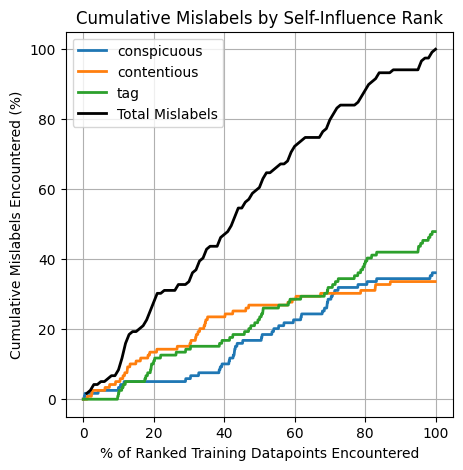

In [43]:
mislabel_types = ["conspicuous", "contentious", "tag"]


self_influence = meta_all[['filepath', 'label', 'avg_normalized']]

# Merge mislabel info into self_influence
mislabel_pivot = mislabel_df.pivot_table(index='filepath', columns='mislabel_type', aggfunc='size', fill_value=0)
mislabel_pivot['mislabelled'] = 1
mislabel_pivot = mislabel_pivot.reset_index()

self_influence = self_influence.merge(mislabel_pivot, on='filepath', how='left')
self_influence['mislabelled'] = self_influence['mislabelled'].fillna(0).astype(int)
# self_influence = self_influence.reset_index(drop=True)
self_influence = self_influence.sort_values(by='avg_normalized', ascending=False)
self_influence['rank'] = np.arange(len(self_influence))

for t in mislabel_types:
    self_influence[t] = self_influence[t].fillna(0).astype(int)


# Cumulative counts per type
for t in mislabel_types:
    if t not in self_influence.columns:
        self_influence[t] = 0

cumulative_counts = {t: [] for t in mislabel_types}
running = {t: 0 for t in mislabel_types}

for _, row in self_influence.iterrows():
    for t in mislabel_types:
        running[t] += row[t]
        cumulative_counts[t].append(running[t])

# Plot
colors = {"conspicuous": "#1f77b4", "contentious": "#ff7f0e", "tag": "#2ca02c"}
plt.figure(figsize=(5, 5))

total_datapoints = len(self_influence)
total_mislabels = self_influence['mislabelled'].sum()

for t in mislabel_types:
    plt.plot(
        100 * self_influence['rank'] / total_datapoints,
        100 * np.array(cumulative_counts[t]) / total_mislabels,
        label=t, color=colors[t], linewidth=2
    )

mislabel_ranks = self_influence[self_influence['mislabelled'] == 1]['rank'].values
K_values = np.arange(10, 1001, 10)
total_counts = [(mislabel_ranks < K).sum() for K in K_values]
plt.plot(
    100 * K_values / total_datapoints,
    100 * np.array(total_counts) / total_mislabels,
    label="Total Mislabels", color='black', linestyle='-', linewidth=2
)

plt.xlabel("% of Ranked Training Datapoints Encountered")
plt.ylabel("Cumulative Mislabels Encountered (%)")
plt.title("Cumulative Mislabels by Self-Influence Rank")
plt.legend()
plt.grid(True, axis='both')
plt.show()

In [67]:
Ks = [5, 10, 20, 50, 100]

for i in Ks:
    K = i*10
    top_K = self_influence.head(K)

    precision_at_K = top_K['mislabelled'].sum() / K
    recall_at_K = top_K['mislabelled'].sum() / total_mislabels
    f1_at_K = 2*(precision_at_K * recall_at_K) / (precision_at_K + recall_at_K)

    print(f"Precision @ {i}%: {precision_at_K:.2f}")
    print(f"Recall @ {i}%: {recall_at_K:.2f}")
    print(f"F1 @ {i}%: {f1_at_K:.2f}")
    
    print("")

Precision @ 5%: 0.44
Recall @ 5%: 0.18
F1 @ 5%: 0.26

Precision @ 10%: 0.37
Recall @ 10%: 0.31
F1 @ 10%: 0.34

Precision @ 20%: 0.27
Recall @ 20%: 0.45
F1 @ 20%: 0.33

Precision @ 50%: 0.20
Recall @ 50%: 0.83
F1 @ 50%: 0.32

Precision @ 100%: 0.12
Recall @ 100%: 1.00
F1 @ 100%: 0.21



In [75]:
Ks = [5, 10, 20, 50, 100]

for i in Ks:
    K = i*10
    top_K = self_influence.head(K)

    total_contentious = self_influence['contentious'].sum()
    
    precision_at_K = top_K['contentious'].sum() / K
    recall_at_K = top_K['contentious'].sum() / total_contentious
    f1_at_K = 2*(precision_at_K * recall_at_K) / (precision_at_K + recall_at_K)

    print(f"Precision @ {i}%: {precision_at_K:.2f}")
    print(f"Recall @ {i}%: {recall_at_K:.2f}")
    print(f"F1 @ {i}%: {f1_at_K:.2f}")
    
    print("")

Precision @ 5%: 0.10
Recall @ 5%: 0.12
F1 @ 5%: 0.11

Precision @ 10%: 0.08
Recall @ 10%: 0.20
F1 @ 10%: 0.11

Precision @ 20%: 0.07
Recall @ 20%: 0.35
F1 @ 20%: 0.12

Precision @ 50%: 0.07
Recall @ 50%: 0.90
F1 @ 50%: 0.13

Precision @ 100%: 0.04
Recall @ 100%: 1.00
F1 @ 100%: 0.08



In [74]:
Ks = [5, 10, 20, 50, 100]

for i in Ks:
    K = i*10
    top_K = self_influence.head(K)

    total_conspicuous = self_influence['conspicuous'].sum()
    
    precision_at_K = top_K['conspicuous'].sum() / K
    recall_at_K = top_K['conspicuous'].sum() / total_conspicuous
    f1_at_K = 2*(precision_at_K * recall_at_K) / (precision_at_K + recall_at_K)

    print(f"Precision @ {i}%: {precision_at_K:.2f}")
    print(f"Recall @ {i}%: {recall_at_K:.2f}")
    print(f"F1 @ {i}%: {f1_at_K:.2f}")
    
    print("")

Precision @ 5%: 0.26
Recall @ 5%: 0.30
F1 @ 5%: 0.28

Precision @ 10%: 0.19
Recall @ 10%: 0.44
F1 @ 10%: 0.27

Precision @ 20%: 0.11
Recall @ 20%: 0.51
F1 @ 20%: 0.18

Precision @ 50%: 0.06
Recall @ 50%: 0.67
F1 @ 50%: 0.11

Precision @ 100%: 0.04
Recall @ 100%: 1.00
F1 @ 100%: 0.08



In [77]:
Ks = [5, 10, 20, 50, 100]

for i in Ks:
    K = i*10
    top_K = self_influence.head(K)

    total_tag = self_influence['tag'].sum()
    
    precision_at_K = top_K['tag'].sum() / K
    recall_at_K = top_K['tag'].sum() / total_tag
    f1_at_K = 2*(precision_at_K * recall_at_K) / (precision_at_K + recall_at_K)

    print(f"Precision @ {i}%: {precision_at_K:.2f}")
    print(f"Recall @ {i}%: {recall_at_K:.2f}")
    print(f"F1 @ {i}%: {f1_at_K:.2f}")
    
    print("")

Precision @ 5%: 0.26
Recall @ 5%: 0.23
F1 @ 5%: 0.24

Precision @ 10%: 0.23
Recall @ 10%: 0.40
F1 @ 10%: 0.29

Precision @ 20%: 0.17
Recall @ 20%: 0.58
F1 @ 20%: 0.26

Precision @ 50%: 0.10
Recall @ 50%: 0.91
F1 @ 50%: 0.19

Precision @ 100%: 0.06
Recall @ 100%: 1.00
F1 @ 100%: 0.11



In [70]:
self_influence

,filepath,label,avg_normalized,conspicuous,contentious,tag,mislabelled,rank
1,./gtzan/pop/pop.00010.wav,7,8.311616e-01,0,0,0,0,0
3,./gtzan/hiphop/hiphop.00031.wav,4,8.218017e-01,1,0,1,1,1
0,./gtzan/disco/disco.00041.wav,3,8.205854e-01,1,0,0,1,2
2,./gtzan/reggae/reggae.00052.wav,8,7.926027e-01,1,0,1,1,3
4,./gtzan/rock/rock.00016.wav,9,7.148464e-01,0,1,0,1,4
...,...,...,...,...,...,...,...,...
994,./gtzan/classical/classical.00014.wav,1,1.695418e-07,0,0,0,0,995
996,./gtzan/classical/classical.00029.wav,1,1.551155e-07,0,0,0,0,996
997,./gtzan/classical/classical.00011.wav,1,1.347167e-07,0,0,0,0,997
998,./gtzan/classical/classical.00022.wav,1,7.870707e-08,0,0,0,0,998
